The purpose of this notebook is to generate plots for the required variance in methane forcing to achieve a given variance in the observed methane time series.

In [1]:
from methane_noise_forcing import closed_form
from hydra import compose, initialize
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from methane_noise_forcing.core import FirnFilter
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

In [2]:
with initialize(version_base=None, config_path="../../configs"):  # configs with data paths
    cfg = compose(config_name="config", overrides=[
        "+noise=white_noise_ar1",
        "++noise.duration_timeseries=4750",
        "+firn_kernel=firn_model_wais",])

In [3]:
## global parameters
variance_filtered_methane = 100 # ppb^2
taus_methane = np.arange(7, 13.2, 0.2) # years

# parameters for sweeping forcing timescale
a, b = -2, 3 # log10 years
m = 10 # samples per decade
num = (b - a) * m + 1 # number of samples
taus_forcing = np.logspace(a, b, num) # years

# lags to calculate
n_lag_years = 80 # number of year lags to calculate

In [4]:
## plotting functions
def plot_da_heat(
    da,
    *,
    ax=None,                 # main plotting axes
    cbar_ax=None,            # optional separate axes for the colorbar
    cmap='Reds',
    log_color=False,         # True => LogNorm for both image & colorbar
    vmin=None,
    vmax=None,
    cbar_label=None,
    cbar_orientation='vertical',  # 'vertical' or 'horizontal'
    tight=False,
    **kwargs
):
    """
    da: xarray.DataArray with dims ('taus_methane', 'taus_forcing')
    Returns: (h, ax, cbar)
    """
    if ax is None:
        ax = plt.gca()

    # Norm controls both the image mapping and the colorbar scale
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax) if log_color else None

    # Build kwargs for xarray's plot
    plot_kwargs = dict(
        x='taus_forcing',
        y='taus_methane',
        ax=ax,
        cmap=cmap,
        norm=norm,
        add_colorbar=True
    )
    if cbar_ax is not None:
        plot_kwargs['cbar_ax'] = cbar_ax
    # Only pass cbar_kwargs if we actually set something, to avoid overriding defaults
    cbar_kwargs = {}
    if cbar_label is not None:
        cbar_kwargs['label'] = cbar_label
    if cbar_orientation != 'vertical':
        cbar_kwargs['orientation'] = cbar_orientation
    if cbar_kwargs:
        plot_kwargs['cbar_kwargs'] = cbar_kwargs

    plot_kwargs.update(kwargs)
    h = da.plot(**plot_kwargs)

    # Axes formatting
    ax.set_xscale('log')
    ax.set_xlabel('Forcing timescale (yr)')
    ax.set_ylabel('Methane lifetime (yr)')
    ax.set_title('')

    # Decimal tick labels on a log x-axis (0.01, 0.1, 1, 10, ...)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    if tight:
        plt.tight_layout()

    # Grab the colorbar (xarray attaches it to the artist)
    cbar = h.colorbar
    return h, ax, cbar

def colorbar_decade_labels(cbar):
    vmin, vmax = cbar.norm.vmin, cbar.norm.vmax
    lo = int(np.ceil(np.log10(vmin)))
    hi = int(np.floor(np.log10(vmax)))
    ticks = [10**e for e in range(lo, hi+1)]
    if ticks:                      # only set if we actually have full decades in-range
        cbar.set_ticks(ticks)
    cbar.formatter = mticker.FuncFormatter(lambda v, pos: f"{v:g}")  # 1, 10, 100...
    cbar.update_ticks()

# generate and visualize kernel self-overlap (autocorrelation)

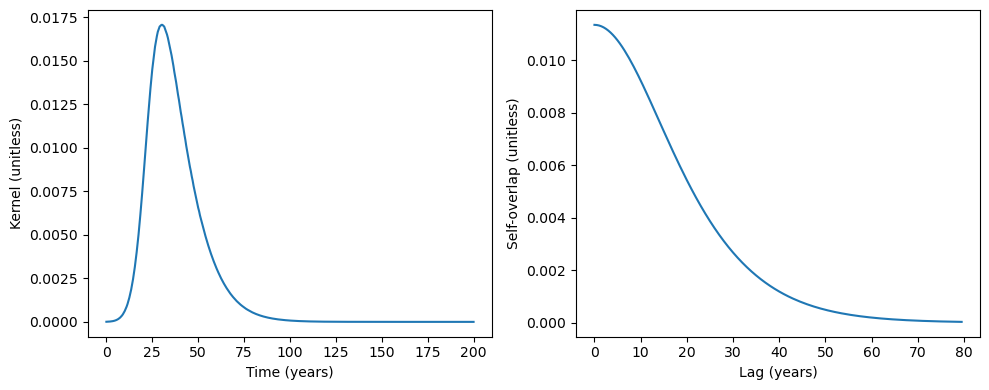

In [ ]:
firn_filter = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
)

dt = firn_filter.dt  # years
lags = np.arange(0, n_lag_years / dt, 1) # years

# normalize kernel by ensuring unit area
# since series dt is equal to kernel dt, we can use the sum of the kernel directly
kernel_normalized = firn_filter.kernel / np.sum(firn_filter.kernel) 

# calculate self-overlap
c_taus = closed_form.calculate_kernel_self_lag(
    kernel=kernel_normalized,
    lags=lags,
)

# plot
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# plot firn filter
time = np.arange(0, kernel_normalized.shape[0] * dt, dt)
axs[0].plot(time, kernel_normalized)
axs[0].set_xlabel("Time (years)")
axs[0].set_ylabel("Kernel (unitless)")

# plot self-overlap
axs[1].plot(lags * dt, c_taus)
axs[1].set_xlabel("Lag (years)")
axs[1].set_ylabel("Self-overlap (unitless)")

plt.tight_layout()

# two-timescale noise

## generate autocorrelations for range of timescales

In [6]:
## iterate over methane lifetimes and forcing timescales to calculate autocorrelation over all lags
#  dimensions of output DataSet: (taus_methane, taus_forcing, lags)
autocorrelation_two_timescale = xr.DataArray(
    np.zeros((len(taus_methane), len(taus_forcing), len(lags))),
    dims=["taus_methane", "taus_forcing", "lags"],
    coords={
        "taus_methane": taus_methane,
        "taus_forcing": taus_forcing,
        "lags": lags,
    },
)
for tau_methane in taus_methane:
    for tau_forcing in taus_forcing:
        autocorrelation = closed_form.calculate_two_timescale_autocorrelation(
            phi_0=np.exp(-dt / tau_methane),
            phi_1=np.exp(-dt / tau_forcing),
            lags=lags,
        )
        autocorrelation_two_timescale.loc[dict(
            taus_methane=tau_methane,
            taus_forcing=tau_forcing,
        )] = autocorrelation

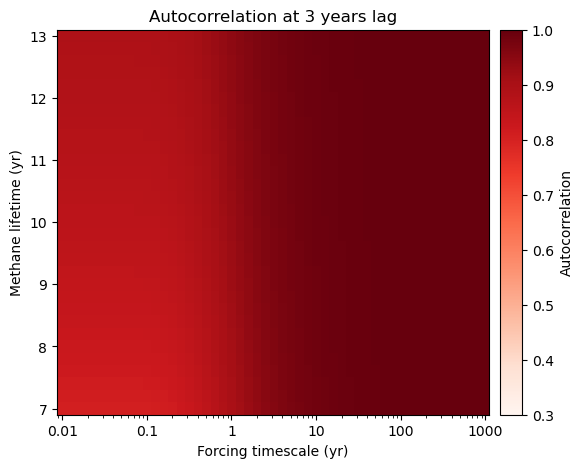

In [7]:
## plot autocorrelations at specific lags
lag_years = 3 # years
da_to_plot = autocorrelation_two_timescale.sel(lags=lag_years)

fig = plt.figure(figsize=(6,5))
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[20, 1], wspace=0.05)
ax  = fig.add_subplot(gs[0,0])
cax = fig.add_subplot(gs[0,1]) 

h, ax, cbar = plot_da_heat(
    da_to_plot,
    ax=ax, cbar_ax=cax,
)
h.set_clim(0.3, 1)
h.set_label('something')
ax.set_title(f'Autocorrelation at {lag_years} years lag')
cbar = h.colorbar
cbar.set_label('Autocorrelation')

## calculate variance required in instantaneous methane and forcing

In [8]:
## iterate over methane lifetimes and forcing timescales to calculate instantaneous methane and forcing variances
#  dimensions of output DataSet: (taus_methane, taus_forcing)
instantaneous_methane_variance = xr.DataArray(
    np.zeros((len(taus_methane), len(taus_forcing))),
    dims=["taus_methane", "taus_forcing"],
    coords={
        "taus_methane": taus_methane,
        "taus_forcing": taus_forcing,
    },
)
forcing_variance = xr.DataArray(
    np.zeros((len(taus_methane), len(taus_forcing))),
    dims=["taus_methane", "taus_forcing"],
    coords={
        "taus_methane": taus_methane,
        "taus_forcing": taus_forcing,
    },
)
for tau_methane in taus_methane:
    for tau_forcing in taus_forcing:
        variance_ratio_filtered_to_instantaneous = closed_form.calculate_variance_ratio_filtered_to_instantaneous(
            c_taus=c_taus,
            instantaneous_autocorrelations=autocorrelation_two_timescale.loc[dict(
                taus_methane=tau_methane,
                taus_forcing=tau_forcing,
            )],
        )
        variance_instantaneous_methane = variance_filtered_methane / variance_ratio_filtered_to_instantaneous
        instantaneous_methane_variance.loc[dict(
            taus_methane=tau_methane,
            taus_forcing=tau_forcing,
        )] = variance_instantaneous_methane

        variance_ratio_methane_to_forcing = closed_form.calculate_two_timescale_variance_ratio_methane_to_ar1_forcing(
            tau_methane=tau_methane,
            tau_forcing=tau_forcing,
        )
        variance_forcing = variance_instantaneous_methane / variance_ratio_methane_to_forcing
        forcing_variance.loc[dict(
            taus_methane=tau_methane,
            taus_forcing=tau_forcing,
        )] = variance_forcing

# convert units of variance from ppb^2/yr^2 to Tg^2/yr^2
# 1 ppb = 2.75 Tg of methane
conversion_factor = 2.75
variance_forcing *= conversion_factor**2

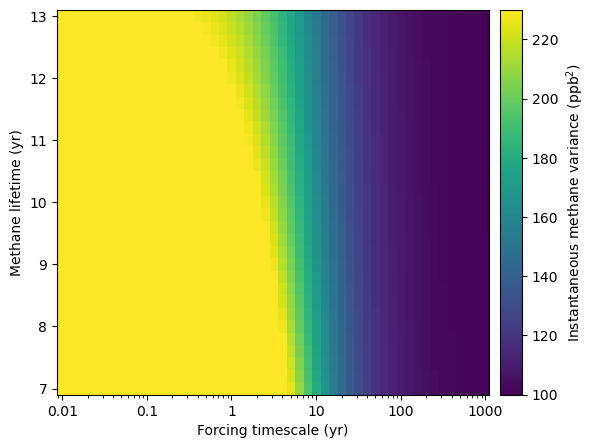

In [9]:
## plot instantaneous methane variance required for a given filtered variance
fig = plt.figure(figsize=(6,5))
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[20, 1], wspace=0.05)
ax  = fig.add_subplot(gs[0,0])
cax = fig.add_subplot(gs[0,1]) 

h, ax, cbar = plot_da_heat(
    instantaneous_methane_variance,
    ax=ax, cbar_ax=cax,
    cmap='viridis',
)
cbar = h.colorbar
cbar.set_label('Instantaneous methane variance (ppb$^2$)')
h.set_clim(100, 230)  

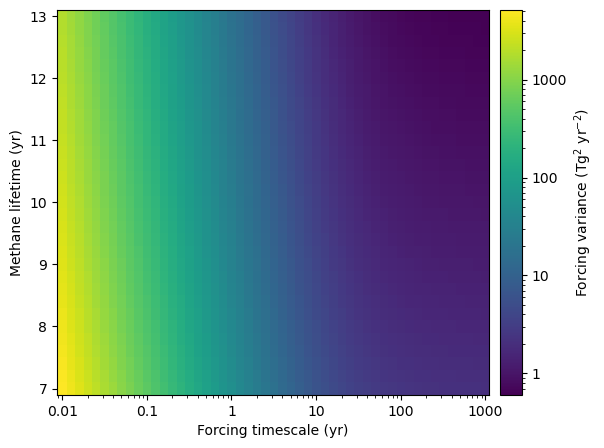

In [10]:
## plot forcing variance required
fig = plt.figure(figsize=(6,5))
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[20, 1], wspace=0.05)
ax  = fig.add_subplot(gs[0,0])
cax = fig.add_subplot(gs[0,1]) 

h, ax, cbar = plot_da_heat(
    forcing_variance,
    ax=ax, cbar_ax=cax,
    cmap='viridis',
    log_color=True,
)
cbar = h.colorbar
cbar.set_label('Forcing variance (Tg$^2$ yr$^{-2}$)')
colorbar_decade_labels(cbar)

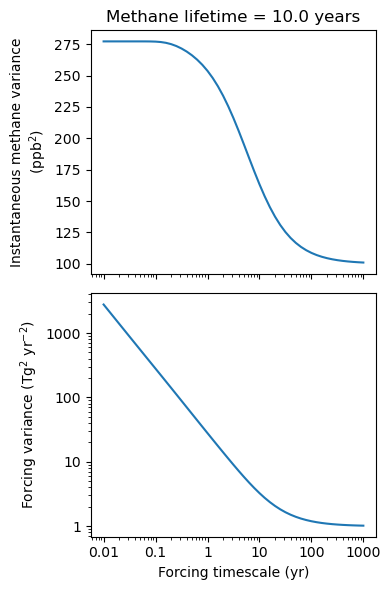

In [11]:
## plot particular methane lifetime
tau_methane = 10.0  # years
da_to_plot_forcing = forcing_variance.sel(taus_methane=tau_methane, method='nearest')
da_to_plot_methane = instantaneous_methane_variance.sel(taus_methane=tau_methane, method='nearest')

fig, axs = plt.subplots(2, 1, figsize=(4, 6), sharex=True)

# instantaneous methane variance
axs[0].plot(
    da_to_plot_methane.taus_forcing,
    da_to_plot_methane,
)
axs[0].set_ylabel('Instantaneous methane variance\n(ppb$^2$)')

axs[1].plot(
    da_to_plot_forcing.taus_forcing,
    da_to_plot_forcing,
)
axs[1].set_ylabel('Forcing variance (Tg$^2$ yr$^{-2}$)')
axs[1].set_yscale('log')
axs[1].yaxis.set_major_locator(mticker.LogLocator(base=10))
axs[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
axs[1].yaxis.set_minor_formatter(mticker.NullFormatter())

axs[1].set_xscale('log')
axs[1].set_xlabel('Forcing timescale (yr)')
axs[1].xaxis.set_major_locator(mticker.LogLocator(base=10))
axs[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
axs[1].xaxis.set_minor_formatter(mticker.NullFormatter())

axs[0].set_title(f'Methane lifetime = {tau_methane} years')

plt.tight_layout()

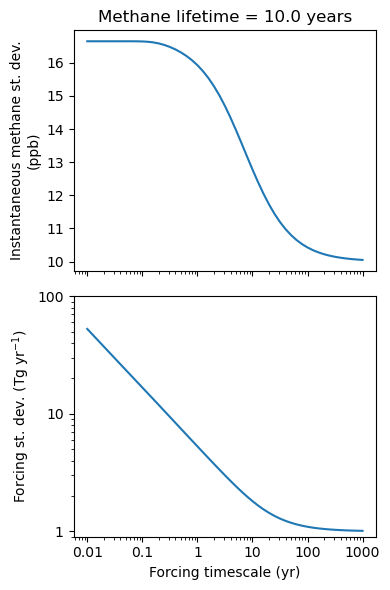

In [12]:
## plot particular methane lifetime (standard deviation version)
tau_methane = 10.0  # years
da_to_plot_forcing = forcing_variance.sel(taus_methane=tau_methane, method='nearest')
da_to_plot_methane = instantaneous_methane_variance.sel(taus_methane=tau_methane, method='nearest')

fig, axs = plt.subplots(2, 1, figsize=(4, 6), sharex=True)

# instantaneous methane variance
axs[0].plot(
    da_to_plot_methane.taus_forcing,
    np.sqrt(da_to_plot_methane),
)
axs[0].set_ylabel('Instantaneous methane st. dev.\n(ppb)')

axs[1].plot(
    da_to_plot_forcing.taus_forcing,
    np.sqrt(da_to_plot_forcing),
)
axs[1].set_ylabel('Forcing st. dev. (Tg yr$^{-1}$)')
axs[1].set_yscale('log')
axs[1].set_ylim(0.9, 100)
axs[1].yaxis.set_major_locator(mticker.LogLocator(base=10))
axs[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
axs[1].yaxis.set_minor_formatter(mticker.NullFormatter())

axs[1].set_xscale('log')
axs[1].set_xlabel('Forcing timescale (yr)')
axs[1].xaxis.set_major_locator(mticker.LogLocator(base=10))
axs[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
axs[1].xaxis.set_minor_formatter(mticker.NullFormatter())

axs[0].set_title(f'Methane lifetime = {tau_methane} years')

plt.tight_layout()